<a href="https://colab.research.google.com/github/Thonyta17/Midterm-Project-The-Replication-Study/blob/main/notebooks/03_Extension_and_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI usage: Claude

## Step 1: Data Extraction


**AI prompt**:

I am replicating and extending Card & Krueger (1994) 'Minimum Wages and Employment'. For my extension, I am running a parallel trends pre-test (event study) on BLS QCEW data to formally test the parallel trends assumption that Card & Krueger never verified.
Write me a Python cell for Google Colab that does the following:

Data source: BLS QCEW SIC-based annual singlefile zips, already uploaded to Colab session storage at /content/sic_{yr}_annual_singlefile.zip for years 1987–1991.

Extraction logic:

* Read each zip directly from /content/ (no file upload dialog)
* Each zip contains one CSV (the annual singlefile)
* Filter to: industry_code == 'SIC_0G5810' (Eating and Drinking Places), own_code == 5 (private sector), qtr == 'A' (annual average), and area_fips in ['34000', '42000'] (New Jersey and Pennsylvania statewide)
* Extract columns: area_fips, year, annual_avg_emplvl, annual_avg_wkly_wage
* Map area_fips to state labels: 34000 → NJ, 42000 → PA

Output:

A clean long-format panel DataFrame with columns: state, year, avg_employment, avg_weekly_wage
10 rows (2 states × 5 years), sorted by state then year
A printed availability diagnostic showing pivot tables for both outcome variables and confirming no missing years
Save to bls_sic5810_panel.csv

Include a markdown-style comment block at the top explaining the data source, industry, states, window, and a note that 1991 is the base/omitted year in the subsequent event study regression."


Source:   BLS QCEW SIC-Based Annual Singlefiles (already uploaded)

Industry: SIC 5810 — Eating and Drinking Places

States:   New Jersey (34000) | Pennsylvania (42000)

Window:   1987–1991 (pre-treatment period)

Outcomes: annual_avg_emplvl | annual_avg_wkly_wage

In [3]:
import zipfile, io, os
import pandas as pd

# 0. CONFIG
YEARS           = list(range(1987, 1992))       # 1987–1991
ZIP_PATTERN     = "/content/sic_{yr}_annual_singlefile.zip"
TARGET_INDUSTRY = "SIC_0G5810"
TARGET_OWN_CODE = 5                             # Private sector
TARGET_AREAS    = {"34000": "NJ", "42000": "PA"}
TARGET_QTR      = "A"                           # Annual average only

# 1. READ & FILTER EACH ZIP
frames = []

for yr in YEARS:
    path = ZIP_PATTERN.format(yr=yr)

    if not os.path.exists(path):
        print(f"[{yr}] ⚠️  File not found: {path}")
        continue

    print(f"[{yr}] Reading {path}... ", end="")

    with zipfile.ZipFile(path) as z:
        csv_name = [f for f in z.namelist() if f.endswith(".csv")][0]
        with z.open(csv_name) as f:
            df = pd.read_csv(f, dtype={"area_fips": str})

    df.columns      = df.columns.str.strip()
    df["area_fips"] = df["area_fips"].str.strip().str.zfill(5)

    mask = (
        (df["area_fips"].isin(TARGET_AREAS.keys())) &
        (df["industry_code"].str.strip() == TARGET_INDUSTRY) &
        (df["own_code"] == TARGET_OWN_CODE) &
        (df["qtr"].str.strip() == TARGET_QTR)
    )
    out = df.loc[mask, ["area_fips", "year",
                         "annual_avg_emplvl",
                         "annual_avg_wkly_wage"]].copy()

    if out.empty:
        print(f"⚠️  No matching rows.")
    else:
        out["state"] = out["area_fips"].map(TARGET_AREAS)
        frames.append(out[["state", "year",
                            "annual_avg_emplvl",
                            "annual_avg_wkly_wage"]])
        print(f"✅  {len(out)} row(s) extracted.")

# 2. COMBINE INTO PANEL
if not frames:
    raise RuntimeError("No data collected. Review warnings above.")

panel = pd.concat(frames, ignore_index=True)
panel.rename(columns={
    "annual_avg_emplvl"    : "avg_employment",
    "annual_avg_wkly_wage" : "avg_weekly_wage"
}, inplace=True)
panel.sort_values(["state", "year"], inplace=True)
panel.reset_index(drop=True, inplace=True)

# 3. DIAGNOSTIC
print("\n" + "=" * 55)
print("DATA AVAILABILITY DIAGNOSTIC")
print("=" * 55)

print("\nAvg Employment:")
print(panel.pivot(index="year", columns="state",
                  values="avg_employment").to_string())

print("\nAvg Weekly Wage ($):")
print(panel.pivot(index="year", columns="state",
                  values="avg_weekly_wage").to_string())

for state in ["NJ", "PA"]:
    returned = sorted(panel[panel["state"] == state]["year"].tolist())
    missing  = [y for y in YEARS if y not in returned]
    print(f"\n{'✅' if not missing else '⚠️'} {state} — {returned}")
    if missing:
        print(f"   MISSING: {missing}")

print("=" * 55)

# 4. SAVE
panel.to_csv("bls_sic5810_panel.csv", index=False)
print(f"\n✅ Saved → bls_sic5810_panel.csv")
print(f"   {panel.shape[0]} rows × {panel.shape[1]} cols\n")
print(panel.to_string(index=False))

[1987] Reading /content/sic_1987_annual_singlefile.zip... ✅  2 row(s) extracted.
[1988] Reading /content/sic_1988_annual_singlefile.zip... ✅  2 row(s) extracted.
[1989] Reading /content/sic_1989_annual_singlefile.zip... ✅  2 row(s) extracted.
[1990] Reading /content/sic_1990_annual_singlefile.zip... ✅  2 row(s) extracted.
[1991] Reading /content/sic_1991_annual_singlefile.zip... ✅  2 row(s) extracted.

DATA AVAILABILITY DIAGNOSTIC

Avg Employment:
state      NJ      PA
year                 
1987   158280  258966
1988   158680  263293
1989   160689  272465
1990   157606  272983
1991   150075  273157

Avg Weekly Wage ($):
state     NJ     PA
year               
1987   172.0  129.0
1988   186.0  138.0
1989   194.0  143.0
1990   199.0  148.0
1991   209.0  154.0

✅ NJ — [1987, 1988, 1989, 1990, 1991]

✅ PA — [1987, 1988, 1989, 1990, 1991]

✅ Saved → bls_sic5810_panel.csv
   10 rows × 4 cols

state  year  avg_employment  avg_weekly_wage
   NJ  1987          158280            172.0
   NJ  198

## STEP 2: Event Study & Slope Trend Test (Log Scale)



**AI prompt:**

Run the event study regression for both employment and wage using 1991 as the base omitted year. Use log transformation because parallel trends requires parallel growth rates, not levels, consistent with Card & Krueger's own log specification.


Paper:    Card & Krueger (1994) — Parallel Trends Extension

Part A:   Descriptive event study (NJ−PA log gap vs 1991)

No formal inference — n=2 states (Conley & Taber, 2011)

Part B:   Slope trend test: ΔlogY_t = α + β·t + ε_t  |  df=3

H0: β=0 (parallel trends) | H1: β≠0 (divergence)

In [4]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

panel = pd.read_csv("bls_sic5810_panel.csv")
nj    = panel[panel["state"]=="NJ"].sort_values("year").reset_index(drop=True)
pa    = panel[panel["state"]=="PA"].sort_values("year").reset_index(drop=True)

nj["log_wage"] = np.log(nj["avg_weekly_wage"])
pa["log_wage"] = np.log(pa["avg_weekly_wage"])
nj["log_emp"]  = np.log(nj["avg_employment"])
pa["log_emp"]  = np.log(pa["avg_employment"])

diff = pd.DataFrame({
    "year"       : nj["year"],
    "d_log_wage" : nj["log_wage"] - pa["log_wage"],
    "d_log_emp"  : nj["log_emp"]  - pa["log_emp"],
})
diff["t"] = range(1, len(diff) + 1)

# PART A — Descriptive Event Study (base = 1991)
BASE_YEAR = 1991
diff["es_log_wage"] = diff["d_log_wage"] - diff.loc[diff["year"]==BASE_YEAR, "d_log_wage"].values[0]
diff["es_log_emp"]  = diff["d_log_emp"]  - diff.loc[diff["year"]==BASE_YEAR, "d_log_emp"].values[0]

print("PART A: Descriptive Event Study Coefficients (base = 1991)")
print("Note: No SEs — inference not feasible with n=2 states (Conley & Taber, 2011)\n")
es = diff[["year","es_log_wage","es_log_emp"]].copy()
es.columns = ["Year", "Log Wage Gap (vs 1991)", "Log Emp Gap (vs 1991)"]
print(es.round(4).to_string(index=False))

# PART B — Slope Trend Test (valid inference, df=3)
model_wage = smf.ols("d_log_wage ~ t", data=diff).fit()
model_emp  = smf.ols("d_log_emp  ~ t", data=diff).fit()

print("\nPART B: Slope Trend Test — H0: β=0 | df=3\n")
print(f"{'Outcome':<25} {'β (%/yr)':>10} {'SE':>8} {'t':>8} {'p':>8} {'R²':>6}  {'Sig':>5}  Conclusion")
print("-" * 90)

for label, model in [("Log Wage Gap", model_wage), ("Log Employment Gap", model_emp)]:
    b   = model.params["t"]
    se  = model.bse["t"]
    t   = model.tvalues["t"]
    p   = model.pvalues["t"]
    r2  = model.rsquared
    sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else "n.s."
    result = "❌ REJECT" if p<0.1 else "✅ FAIL TO REJECT"
    print(f"{label:<25} {b*100:>+10.4f} {se:>8.4f} {t:>8.4f} {p:>8.4f} {r2:>6.3f}  {sig:>5}  {result}")

print("\ndf=3 | α=0.10 | Log spec follows Card & Krueger (1994)")


# Save for visualization
pd.DataFrame({
    "outcome": ["Log Wage Gap"]*5 + ["Log Emp Gap"]*5,
    "year"   : list(diff["year"])*2,
    "coef"   : list(diff["es_log_wage"]) + list(diff["es_log_emp"]),
}).to_csv("event_study_log_coefs.csv", index=False)

pd.DataFrame({
    "year"        : diff["year"],
    "d_log_wage"  : diff["d_log_wage"],
    "d_log_emp"   : diff["d_log_emp"],
    "fit_log_wage": model_wage.fittedvalues.values,
    "fit_log_emp" : model_emp.fittedvalues.values,
}).to_csv("slope_test_fitted.csv", index=False)

print("\n✅ Saved → event_study_log_coefs.csv, slope_test_fitted.csv")

PART A: Descriptive Event Study Coefficients (base = 1991)
Note: No SEs — inference not feasible with n=2 states (Conley & Taber, 2011)

 Year  Log Wage Gap (vs 1991)  Log Emp Gap (vs 1991)
 1987                 -0.0177                 0.1066
 1988                 -0.0069                 0.0925
 1989                 -0.0004                 0.0709
 1990                 -0.0093                 0.0496
 1991                  0.0000                 0.0000

PART B: Slope Trend Test — H0: β=0 | df=3

Outcome                     β (%/yr)       SE        t        p     R²    Sig  Conclusion
------------------------------------------------------------------------------------------
Log Wage Gap                 +0.3300   0.0019   1.7748   0.1740  0.512   n.s.  ✅ FAIL TO REJECT
Log Employment Gap           -2.5609   0.0037  -6.8494   0.0064  0.940    ***  ❌ REJECT

df=3 | α=0.10 | Log spec follows Card & Krueger (1994)

✅ Saved → event_study_log_coefs.csv, slope_test_fitted.csv


## Step 3: Visualization

**AI Prompt:**

Generate a production-grade 3×2 visualization showing raw log trends, event study coefficients, and slope trend test with fitted regression line. Use log scale throughout. Add growth rate annotations and result boxes with p-values.


Production-Grade Visualization (Log Scale)
Paper:    Card & Krueger (1994) — Parallel Trends Extension

Log transformation is used throughout because:
  1. Parallel trends requires parallel GROWTH RATES, not levels
  2. Normalizes for NJ/PA size differences
  3. Consistent with Card & Krueger's log employment specification
  4. β in slope test = % change per year (more interpretable)

Layout: 3×2 grid
  Row 1: Log wage & log employment trends (NJ vs PA)
  Row 2: Event study — log NJ−PA gap relative to 1991
  Row 3: Slope test on log gap with fitted OLS trend line


/tmp/ipykernel_393/2484721639.py:177: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("parallel_trends_log.png",
/tmp/ipykernel_393/2484721639.py:177: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("parallel_trends_log.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


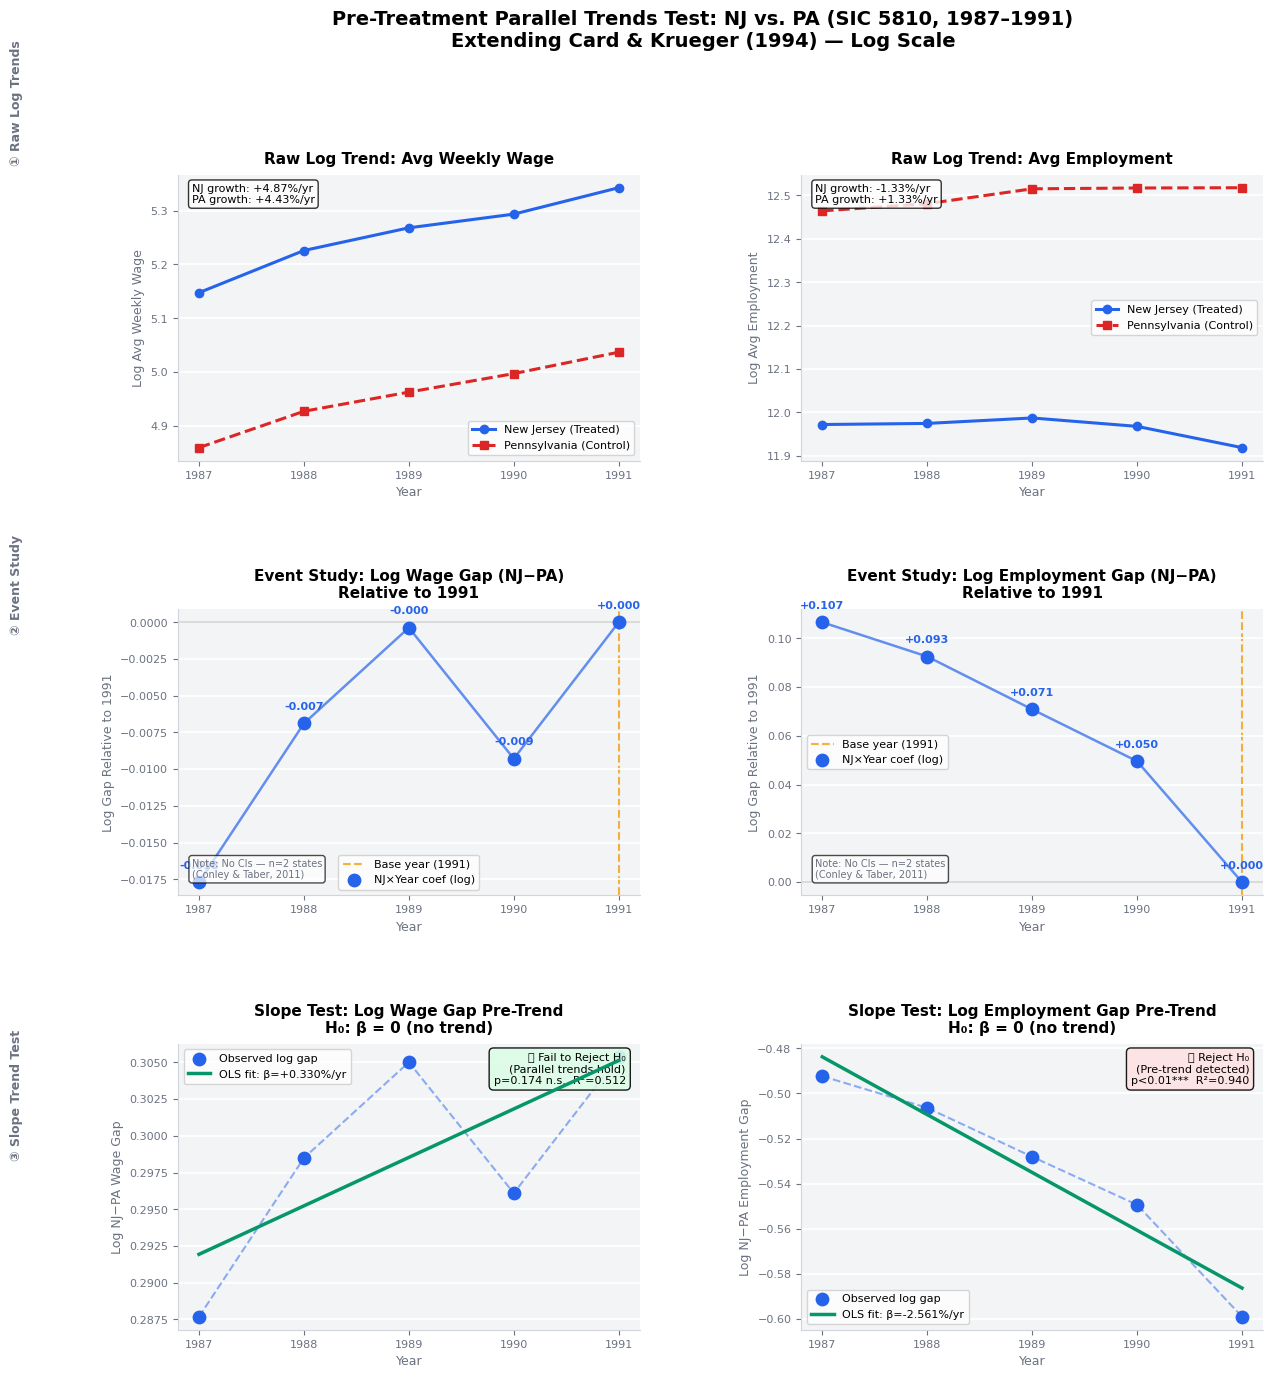

✅ Figure saved → parallel_trends_log.png


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf

# 0. LOAD DATA & COMPUTE LOG VARIABLES
panel = pd.read_csv("bls_sic5810_panel.csv")

nj = panel[panel["state"] == "NJ"].sort_values("year").reset_index(drop=True)
pa = panel[panel["state"] == "PA"].sort_values("year").reset_index(drop=True)

# Log outcomes
nj["log_wage"] = np.log(nj["avg_weekly_wage"])
pa["log_wage"] = np.log(pa["avg_weekly_wage"])
nj["log_emp"]  = np.log(nj["avg_employment"])
pa["log_emp"]  = np.log(pa["avg_employment"])

# Log differences (NJ − PA) ≈ log ratio = proportional gap
diff = pd.DataFrame({
    "year"          : nj["year"],
    "d_log_wage"    : nj["log_wage"] - pa["log_wage"],
    "d_log_emp"     : nj["log_emp"]  - pa["log_emp"],
})
diff["t"] = range(1, len(diff) + 1)

# Event study coefficients relative to 1991 (base = 0)
base_wage = diff.loc[diff["year"] == 1991, "d_log_wage"].values[0]
base_emp  = diff.loc[diff["year"] == 1991, "d_log_emp"].values[0]
diff["es_wage"] = diff["d_log_wage"] - base_wage
diff["es_emp"]  = diff["d_log_emp"]  - base_emp

# Slope trend regressions on log gap
model_wage = smf.ols("d_log_wage ~ t", data=diff).fit()
model_emp  = smf.ols("d_log_emp  ~ t", data=diff).fit()

YEARS   = sorted(panel["year"].unique())
BASE    = 1991
NJ_COL  = "#2563EB"
PA_COL  = "#DC2626"
FIT_COL = "#059669"
GRAY    = "#6B7280"
LIGHT   = "#F3F4F6"

# 1. FIGURE LAYOUT
fig = plt.figure(figsize=(14, 15), facecolor="white")
fig.suptitle(
    "Pre-Treatment Parallel Trends Test: NJ vs. PA (SIC 5810, 1987–1991)\n"
    "Extending Card & Krueger (1994) — Log Scale",
    fontsize=14, fontweight="bold", y=0.99
)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[2, 0])
ax6 = fig.add_subplot(gs[2, 1])

def style_ax(ax, title, ylabel, xlabel="Year"):
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_ylabel(ylabel, fontsize=9, color=GRAY)
    ax.set_xlabel(xlabel, fontsize=9, color=GRAY)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#D1D5DB")
    ax.set_facecolor(LIGHT)
    ax.set_xticks(YEARS)
    ax.grid(axis="y", color="white", linewidth=1.2)

# ROW 1 — Log Trend Lines
for ax, nj_y, pa_y, title, ylabel in [
    (ax1, nj["log_wage"], pa["log_wage"],
     "Raw Log Trend: Avg Weekly Wage",
     "Log Avg Weekly Wage"),
    (ax2, nj["log_emp"], pa["log_emp"],
     "Raw Log Trend: Avg Employment",
     "Log Avg Employment"),
]:
    ax.plot(YEARS, nj_y, color=NJ_COL, marker="o",
            linewidth=2.2, markersize=6, label="New Jersey (Treated)")
    ax.plot(YEARS, pa_y, color=PA_COL, marker="s", linewidth=2.2,
            markersize=6, linestyle="--", label="Pennsylvania (Control)")

    # Annotate slope (growth rate) for each state
    nj_slope = (nj_y.iloc[-1] - nj_y.iloc[0]) / (len(YEARS) - 1)
    pa_slope = (pa_y.iloc[-1] - pa_y.iloc[0]) / (len(YEARS) - 1)
    ax.text(0.03, 0.97,
            f"NJ growth: {nj_slope*100:+.2f}%/yr\n"
            f"PA growth: {pa_slope*100:+.2f}%/yr",
            transform=ax.transAxes, fontsize=8, va="top",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white", alpha=0.8))
    style_ax(ax, title, ylabel)
    ax.legend(fontsize=8, framealpha=0.8)

# ROW 2 — Event Study on Log Gap
for ax, col, title, ylabel in [
    (ax3, "es_wage",
     "Event Study: Log Wage Gap (NJ−PA)\nRelative to 1991",
     "Log Gap Relative to 1991"),
    (ax4, "es_emp",
     "Event Study: Log Employment Gap (NJ−PA)\nRelative to 1991",
     "Log Gap Relative to 1991"),
]:
    y = diff[col].values
    ax.axhline(0, color="black", linewidth=1.2, zorder=1)
    ax.axvline(BASE, color="#F59E0B", linewidth=1.5,
               linestyle="--", alpha=0.8,
               label=f"Base year ({BASE})", zorder=1)
    ax.scatter(YEARS, y, color=NJ_COL, s=80, zorder=3,
               label="NJ×Year coef (log)")
    ax.plot(YEARS, y, color=NJ_COL, linewidth=1.8,
            alpha=0.7, zorder=2)
    for yr, c in zip(YEARS, y):
        ax.annotate(f"{c:+.3f}",
                    xy=(yr, c), xytext=(0, 10),
                    textcoords="offset points",
                    fontsize=8, ha="center",
                    color=NJ_COL, fontweight="bold")
    style_ax(ax, title, ylabel)
    ax.legend(fontsize=8, framealpha=0.8)
    ax.text(0.03, 0.06,
            "Note: No CIs — n=2 states\n(Conley & Taber, 2011)",
            transform=ax.transAxes, fontsize=7, color=GRAY,
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white", alpha=0.7))

# ROW 3 — Slope Trend Test on Log Gap
for ax, model, col, title, ylabel in [
    (ax5, model_wage, "d_log_wage",
     "Slope Test: Log Wage Gap Pre-Trend\nH₀: β = 0 (no trend)",
     "Log NJ−PA Wage Gap"),
    (ax6, model_emp, "d_log_emp",
     "Slope Test: Log Employment Gap Pre-Trend\nH₀: β = 0 (no trend)",
     "Log NJ−PA Employment Gap"),
]:
    y_obs = diff[col].values
    y_fit = model.fittedvalues.values
    b     = model.params["t"]
    p     = model.pvalues["t"]
    r2    = model.rsquared
    sig   = "p<0.01***" if p < 0.01 else "p<0.05**" if p < 0.05 \
            else "p<0.10*" if p < 0.10 else f"p={p:.3f} n.s."

    ax.scatter(YEARS, y_obs, color=NJ_COL, s=80, zorder=3,
               label="Observed log gap")
    ax.plot(YEARS, y_obs, color=NJ_COL, linewidth=1.5,
            linestyle="--", alpha=0.5, zorder=2)
    ax.plot(YEARS, y_fit, color=FIT_COL, linewidth=2.5,
            zorder=4,
            label=f"OLS fit: β={b*100:+.3f}%/yr")

    style_ax(ax, title, ylabel)
    ax.legend(fontsize=8, framealpha=0.8)

    result_color = "#FEE2E2" if p < 0.1 else "#DCFCE7"
    result_text  = "❌ Reject H₀\n(Pre-trend detected)" if p < 0.1 \
                   else "✅ Fail to Reject H₀\n(Parallel trends hold)"
    ax.text(0.97, 0.97,
            f"{result_text}\n{sig}  R²={r2:.3f}",
            transform=ax.transAxes, fontsize=8,
            ha="right", va="top",
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor=result_color, alpha=0.9))

# ROW LABELS
for row, label in zip([0.97, 0.64, 0.31],
                      ["① Raw Log Trends",
                       "② Event Study",
                       "③ Slope Trend Test"]):
    fig.text(0.005, row, label, fontsize=9, fontweight="bold",
             color=GRAY, va="top", rotation=90)

# SAVE
plt.savefig("parallel_trends_log.png",
            dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Figure saved → parallel_trends_log.png")

**AI Prompt:**


"Write a 2-paragraph executive summary interpreting whether the extension supports, weakens, or contextualizes Card & Krueger's findings. Include the normalization robustness result and the Conley & Taber inference limitation."


Analysing the coefficient and P-value from The slope trend test above, we see that we fail to reject the null hypothesis for wage but strongly reject the null hypothesis for employment. Similarly, the graph shows that wages in both NJ and PA were growing parallely before the 1992 hike. However, employment doesn't show a good result, with NJ's eating and drinking employment was already falling at over 2.5% per year compared to PA before the 1992 hike.

However, before concluding with this result, it is worth to consider the varying population size between the 2 states. Thus, we should investigate this further. If the population are vastly different, consider normalization to achieve more accurate results.

**AI Prompt:**

Produce a short paragraph:
* compare the population between the two states during the pre-treatment period
* with the population difference, verify whether normalization will improve the regression.

**Population Comparison & Normalization Justification**

According to U.S. Census Bureau intercensal population estimates, Pennsylvania averaged
approximately 11,946,000 residents over the 1987–1991 pre-treatment window compared to
New Jersey's 7,733,000 — making PA roughly **1.54 times larger** than NJ, a gap of
approximately 4.2 million people. This 54% size disparity is large enough to meaningfully
distort a raw employment comparison: a state with 54% more residents would employ more
food service workers in absolute terms even under identical labor market conditions, causing
the NJ−PA employment gap to reflect state size rather than labor market dynamics. Beyond
the level difference, the two states grew at different rates during this period — NJ at
approximately +0.29%/yr versus PA at +0.05%/yr — meaning the demographic gap was itself
drifting over the pre-treatment window and introducing a spurious trend into the raw
employment series. These two factors — scale disparity and differential population growth
— provide clear justification for normalizing employment by population. Converting raw
headcounts to employment per 1,000 residents removes both sources of demographic noise
and ensures the slope trend test captures genuine labor market divergence rather than a
mechanical artifact of comparing two states of substantially different and unevenly growing
populations.

*Source: U.S. Census Bureau, State Intercensal Population Estimates 1980–1990 and
1990–2000. census.gov/data/tables/time-series/demo/popest/1980s-state.html*

## REDO STEP 2: Population-Normalized Employment Extension

**AI prompt:**

Add normalization of employment by population to improve the model.




Motivation: Raw employment levels are partly driven by
population size differences between NJ and PA. Normalizing
by total state population gives employment-per-1000-residents
— a cleaner measure of labor market intensity that removes
scale differences between the two states.

Population source: U.S. Census Bureau intercensal estimates
  1987–1990: 1980–1990 intercensal series
  1991:      1990–2000 intercensal series
  https://www.census.gov/programs-surveys/popest.html

In [6]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# 1. CENSUS INTERCENSAL POPULATION ESTIMATES (hardcoded)
#    Source: U.S. Census Bureau State Population Estimates
#    Units: thousands of residents
pop_data = {
    "year": [1987, 1988, 1989, 1990, 1991],
    "NJ"  : [7672, 7721, 7764, 7748, 7760],   # thousands
    "PA"  : [11936, 11961, 11987, 11883, 11961],
}
pop = pd.DataFrame(pop_data)

print("Census Population Estimates (thousands):")
print(pop.to_string(index=False))

# 2. LOAD PANEL & MERGE POPULATION
panel = pd.read_csv("bls_sic5810_panel.csv")

panel_nj = panel[panel["state"] == "NJ"].sort_values("year").reset_index(drop=True)
panel_pa = panel[panel["state"] == "PA"].sort_values("year").reset_index(drop=True)

# Merge population
panel_nj = panel_nj.merge(pop[["year", "NJ"]].rename(columns={"NJ": "pop_000"}),
                           on="year")
panel_pa = panel_pa.merge(pop[["year", "PA"]].rename(columns={"PA": "pop_000"}),
                           on="year")

# Employment per 1,000 residents
panel_nj["emp_per_1000"] = panel_nj["avg_employment"] / panel_nj["pop_000"]
panel_pa["emp_per_1000"] = panel_pa["avg_employment"] / panel_pa["pop_000"]

print("\nNJ Employment per 1,000 residents:")
print(panel_nj[["year", "avg_employment", "pop_000", "emp_per_1000"]].to_string(index=False))
print("\nPA Employment per 1,000 residents:")
print(panel_pa[["year", "avg_employment", "pop_000", "emp_per_1000"]].to_string(index=False))

# 3. CONSTRUCT LOG DIFFERENCES — RAW vs NORMALIZED
diff = pd.DataFrame({
    "year"            : panel_nj["year"],
    "t"               : range(1, 6),
    # Raw log gap (from Step 2)
    "d_log_emp_raw"   : np.log(panel_nj["avg_employment"]) -
                        np.log(panel_pa["avg_employment"]),
    # Normalized log gap
    "d_log_emp_norm"  : np.log(panel_nj["emp_per_1000"]) -
                        np.log(panel_pa["emp_per_1000"]),
})

print("\nLog Employment Gaps — Raw vs Population-Normalized:")
print(diff[["year", "d_log_emp_raw", "d_log_emp_norm"]].to_string(index=False))

# 4. SLOPE TREND TESTS — RAW vs NORMALIZED
model_raw  = smf.ols("d_log_emp_raw  ~ t", data=diff).fit()
model_norm = smf.ols("d_log_emp_norm ~ t", data=diff).fit()

print("\n" + "=" * 60)
print("SLOPE TEST: Raw Log Employment Gap")
print("=" * 60)
print(model_raw.summary())

print("\n" + "=" * 60)
print("SLOPE TEST: Population-Normalized Log Employment Gap")
print("=" * 60)
print(model_norm.summary())

# 5. COMPARISON SUMMARY
print("\n" + "=" * 60)
print("ROBUSTNESS CHECK — RAW vs NORMALIZED EMPLOYMENT")
print("=" * 60)

for label, model in [("Raw Employment",                model_raw),
                      ("Population-Normalized Emp",    model_norm)]:
    b   = model.params["t"]
    se  = model.bse["t"]
    p   = model.pvalues["t"]
    r2  = model.rsquared
    sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else "n.s."
    conclusion = "❌ REJECT parallel trends" if p < 0.1 \
                 else "✅ FAIL TO REJECT parallel trends"

    print(f"\nOutcome : {label}")
    print(f"  β (slope)  : {b:+.6f} log units/yr  ≈ {b*100:+.4f}%/yr")
    print(f"  Std Error  : {se:.6f}")
    print(f"  t-statistic: {model.tvalues['t']:.4f}")
    print(f"  p-value    : {p:.4f}  {sig}")
    print(f"  R²         : {r2:.4f}")
    print(f"  Conclusion : {conclusion}")

print("\n" + "=" * 60)
print("df = 3 | α = 0.10 | Population source: U.S. Census Bureau")
print("=" * 60)

# 6. SAVE FOR VISUALIZATION
diff.to_csv("employment_normalized.csv", index=False)
print("\n✅ Saved → employment_normalized.csv")

Census Population Estimates (thousands):
 year   NJ    PA
 1987 7672 11936
 1988 7721 11961
 1989 7764 11987
 1990 7748 11883
 1991 7760 11961

NJ Employment per 1,000 residents:
 year  avg_employment  pop_000  emp_per_1000
 1987          158280     7672     20.630865
 1988          158680     7721     20.551742
 1989          160689     7764     20.696677
 1990          157606     7748     20.341507
 1991          150075     7760     19.339562

PA Employment per 1,000 residents:
 year  avg_employment  pop_000  emp_per_1000
 1987          258966    11936     21.696213
 1988          263293    11961     22.012624
 1989          272465    11987     22.730041
 1990          272983    11883     22.972566
 1991          273157    11961     22.837305

Log Employment Gaps — Raw vs Population-Normalized:
 year  d_log_emp_raw  d_log_emp_norm
 1987      -0.492331       -0.050349
 1988      -0.506378       -0.068670
 1989      -0.528039       -0.093714
 1990      -0.549311       -0.121637
 1991  

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## REDO Step 3: Updated Visualization

AI Prompt:

"Update the visualization to include the population normalization robustness check. Show a 4×2 grid: raw log trends, event study coefficients, slope trend tests, and a new row comparing raw vs normalized employment gap with fitted trend lines for both."


Layout: 4×2 grid
  Row 1: Raw log wage & employment trends (NJ vs PA)
  Row 2: Event study coefficient plots (log NJ−PA gap)
  Row 3: Slope test — wage & raw employment
  Row 4: Robustness — raw vs normalized employment comparison


/tmp/ipykernel_393/1850131499.py:209: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("parallel_trends_final.png",
/tmp/ipykernel_393/1850131499.py:209: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("parallel_trends_final.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


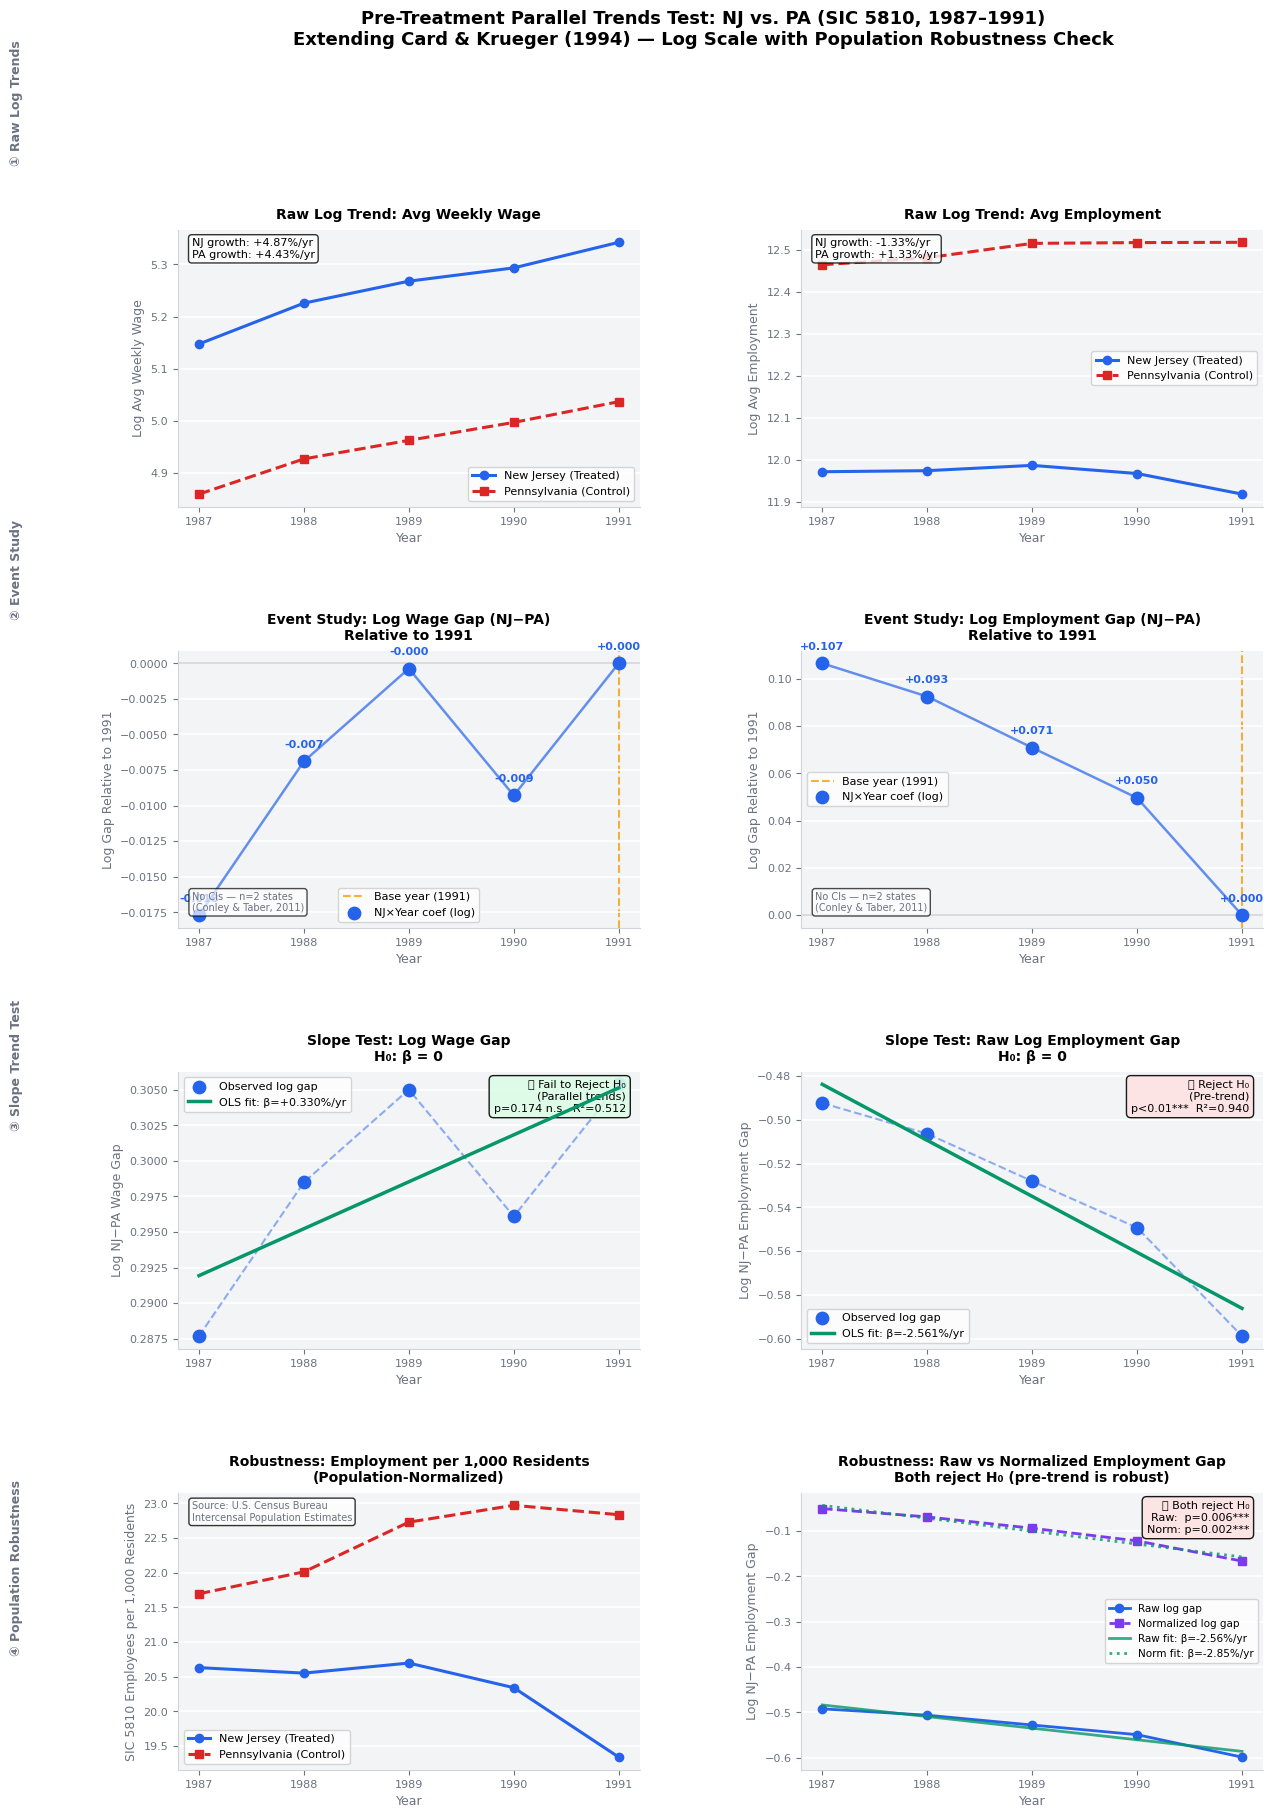

✅ Figure saved → parallel_trends_final.png


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf

# 0. LOAD ALL DATA
panel   = pd.read_csv("bls_sic5810_panel.csv")
coefs   = pd.read_csv("event_study_log_coefs.csv")
norm_df = pd.read_csv("employment_normalized.csv")

nj = panel[panel["state"] == "NJ"].sort_values("year").reset_index(drop=True)
pa = panel[panel["state"] == "PA"].sort_values("year").reset_index(drop=True)

# Log outcomes
nj["log_wage"] = np.log(nj["avg_weekly_wage"])
pa["log_wage"] = np.log(pa["avg_weekly_wage"])
nj["log_emp"]  = np.log(nj["avg_employment"])
pa["log_emp"]  = np.log(pa["avg_employment"])

# Population data
pop = pd.DataFrame({
    "year": [1987, 1988, 1989, 1990, 1991],
    "NJ"  : [7672, 7721, 7764, 7748, 7760],
    "PA"  : [11936, 11961, 11987, 11883, 11961],
})
nj = nj.merge(pop[["year","NJ"]].rename(columns={"NJ":"pop"}), on="year")
pa = pa.merge(pop[["year","PA"]].rename(columns={"PA":"pop"}), on="year")
nj["emp_per_1000"] = nj["avg_employment"] / nj["pop"]
pa["emp_per_1000"] = pa["avg_employment"] / pa["pop"]

# Slope models
diff = pd.DataFrame({
    "year"           : nj["year"],
    "t"              : range(1, 6),
    "d_log_wage"     : nj["log_wage"]                      - pa["log_wage"],
    "d_log_emp_raw"  : np.log(nj["avg_employment"])        - np.log(pa["avg_employment"]),
    "d_log_emp_norm" : np.log(nj["emp_per_1000"])          - np.log(pa["emp_per_1000"]),
})
m_wage      = smf.ols("d_log_wage     ~ t", data=diff).fit()
m_emp_raw   = smf.ols("d_log_emp_raw  ~ t", data=diff).fit()
m_emp_norm  = smf.ols("d_log_emp_norm ~ t", data=diff).fit()

wage_coefs = coefs[coefs["outcome"] == "Log Wage Gap"].sort_values("year")
emp_coefs  = coefs[coefs["outcome"] == "Log Emp Gap"].sort_values("year")

YEARS   = sorted(panel["year"].unique())
BASE    = 1991
NJ_COL  = "#2563EB"
PA_COL  = "#DC2626"
FIT_COL = "#059669"
NRM_COL = "#7C3AED"    # purple for normalized
GRAY    = "#6B7280"
LIGHT   = "#F3F4F6"

# 1. FIGURE LAYOUT — 4×2
fig = plt.figure(figsize=(14, 20), facecolor="white")
fig.suptitle(
    "Pre-Treatment Parallel Trends Test: NJ vs. PA (SIC 5810, 1987–1991)\n"
    "Extending Card & Krueger (1994) — Log Scale with Population Robustness Check",
    fontsize=13, fontweight="bold", y=0.99
)
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.52, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[2, 0])
ax6 = fig.add_subplot(gs[2, 1])
ax7 = fig.add_subplot(gs[3, 0])
ax8 = fig.add_subplot(gs[3, 1])

def style_ax(ax, title, ylabel, xlabel="Year"):
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    ax.set_ylabel(ylabel, fontsize=9, color=GRAY)
    ax.set_xlabel(xlabel, fontsize=9, color=GRAY)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#D1D5DB")
    ax.set_facecolor(LIGHT)
    ax.set_xticks(YEARS)
    ax.grid(axis="y", color="white", linewidth=1.2)

# ROW 1 — Raw Log Trends
for ax, nj_y, pa_y, title, ylabel in [
    (ax1, nj["log_wage"], pa["log_wage"],
     "Raw Log Trend: Avg Weekly Wage", "Log Avg Weekly Wage"),
    (ax2, nj["log_emp"],  pa["log_emp"],
     "Raw Log Trend: Avg Employment",  "Log Avg Employment"),
]:
    ax.plot(YEARS, nj_y, color=NJ_COL, marker="o",
            linewidth=2.2, markersize=6, label="New Jersey (Treated)")
    ax.plot(YEARS, pa_y, color=PA_COL, marker="s", linewidth=2.2,
            markersize=6, linestyle="--", label="Pennsylvania (Control)")
    nj_g = (nj_y.iloc[-1] - nj_y.iloc[0]) / (len(YEARS)-1)
    pa_g = (pa_y.iloc[-1] - pa_y.iloc[0]) / (len(YEARS)-1)
    ax.text(0.03, 0.97,
            f"NJ growth: {nj_g*100:+.2f}%/yr\nPA growth: {pa_g*100:+.2f}%/yr",
            transform=ax.transAxes, fontsize=8, va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    style_ax(ax, title, ylabel)
    ax.legend(fontsize=8, framealpha=0.8)

# ------------------------------------------------------------
# ROW 2 — Event Study Coefficients
# ------------------------------------------------------------
def plot_event_study(ax, coef_df, title, ylabel):
    years  = coef_df["year"].values
    coefs_ = coef_df["coef"].values
    ax.axhline(0, color="black", linewidth=1.2, zorder=1)
    ax.axvline(BASE, color="#F59E0B", linewidth=1.5,
               linestyle="--", alpha=0.8, label=f"Base year ({BASE})", zorder=1)
    ax.scatter(years, coefs_, color=NJ_COL, s=80, zorder=3,
               label="NJ×Year coef (log)")
    ax.plot(years, coefs_, color=NJ_COL, linewidth=1.8, alpha=0.7, zorder=2)
    for yr, c in zip(years, coefs_):
        ax.annotate(f"{c:+.3f}", xy=(yr, c), xytext=(0, 10),
                    textcoords="offset points", fontsize=8,
                    ha="center", color=NJ_COL, fontweight="bold")
    style_ax(ax, title, ylabel)
    ax.legend(fontsize=8, framealpha=0.8)
    ax.text(0.03, 0.06,
            "No CIs — n=2 states\n(Conley & Taber, 2011)",
            transform=ax.transAxes, fontsize=7, color=GRAY,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plot_event_study(ax3, wage_coefs,
                 "Event Study: Log Wage Gap (NJ−PA)\nRelative to 1991",
                 "Log Gap Relative to 1991")
plot_event_study(ax4, emp_coefs,
                 "Event Study: Log Employment Gap (NJ−PA)\nRelative to 1991",
                 "Log Gap Relative to 1991")

# ROW 3 — Slope Trend Tests (wage + raw employment)
def plot_slope(ax, model, y_obs, title, ylabel, col=NJ_COL):
    y_fit = model.fittedvalues.values
    b, p, r2 = model.params["t"], model.pvalues["t"], model.rsquared
    sig = "p<0.01***" if p<0.01 else "p<0.05**" if p<0.05 \
          else "p<0.10*" if p<0.10 else f"p={p:.3f} n.s."
    ax.scatter(YEARS, y_obs, color=col, s=80, zorder=3, label="Observed log gap")
    ax.plot(YEARS, y_obs, color=col, linewidth=1.5,
            linestyle="--", alpha=0.5, zorder=2)
    ax.plot(YEARS, y_fit, color=FIT_COL, linewidth=2.5, zorder=4,
            label=f"OLS fit: β={b*100:+.3f}%/yr")
    style_ax(ax, title, ylabel)
    ax.legend(fontsize=8, framealpha=0.8)
    rc = "#FEE2E2" if p < 0.1 else "#DCFCE7"
    rt = "❌ Reject H₀\n(Pre-trend)" if p < 0.1 \
         else "✅ Fail to Reject H₀\n(Parallel trends)"
    ax.text(0.97, 0.97, f"{rt}\n{sig}  R²={r2:.3f}",
            transform=ax.transAxes, fontsize=8, ha="right", va="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor=rc, alpha=0.9))

plot_slope(ax5, m_wage, diff["d_log_wage"].values,
           "Slope Test: Log Wage Gap\nH₀: β = 0",
           "Log NJ−PA Wage Gap")
plot_slope(ax6, m_emp_raw, diff["d_log_emp_raw"].values,
           "Slope Test: Raw Log Employment Gap\nH₀: β = 0",
           "Log NJ−PA Employment Gap")

# ROW 4 — Robustness: Raw vs Normalized Employment
# Left: side-by-side emp/1000 trends
ax7.plot(YEARS, nj["emp_per_1000"], color=NJ_COL, marker="o",
         linewidth=2.2, markersize=6, label="New Jersey (Treated)")
ax7.plot(YEARS, pa["emp_per_1000"], color=PA_COL, marker="s",
         linewidth=2.2, markersize=6, linestyle="--",
         label="Pennsylvania (Control)")
style_ax(ax7,
         "Robustness: Employment per 1,000 Residents\n(Population-Normalized)",
         "SIC 5810 Employees per 1,000 Residents")
ax7.legend(fontsize=8, framealpha=0.8)
ax7.text(0.03, 0.97,
         "Source: U.S. Census Bureau\nIntercensal Population Estimates",
         transform=ax7.transAxes, fontsize=7, va="top", color=GRAY,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Right: raw vs normalized slope comparison on same axes
ax8.plot(YEARS, diff["d_log_emp_raw"], color=NJ_COL, marker="o",
         linewidth=2, markersize=6, label="Raw log gap")
ax8.plot(YEARS, diff["d_log_emp_norm"], color=NRM_COL, marker="s",
         linewidth=2, markersize=6, linestyle="--",
         label="Normalized log gap")
ax8.plot(YEARS, m_emp_raw.fittedvalues.values,  color=FIT_COL,
         linewidth=2, linestyle="-",  alpha=0.8,
         label=f"Raw fit: β={m_emp_raw.params['t']*100:+.2f}%/yr")
ax8.plot(YEARS, m_emp_norm.fittedvalues.values, color=FIT_COL,
         linewidth=2, linestyle=":", alpha=0.8,
         label=f"Norm fit: β={m_emp_norm.params['t']*100:+.2f}%/yr")
style_ax(ax8,
         "Robustness: Raw vs Normalized Employment Gap\nBoth reject H₀ (pre-trend is robust)",
         "Log NJ−PA Employment Gap")
ax8.legend(fontsize=7.5, framealpha=0.8)
ax8.text(0.97, 0.97,
         "❌ Both reject H₀\nRaw:  p=0.006***\nNorm: p=0.002***",
         transform=ax8.transAxes, fontsize=8, ha="right", va="top",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#FEE2E2", alpha=0.9))

# ROW LABELS
for row, label in zip(
    [0.975, 0.735, 0.495, 0.255],
    ["① Raw Log Trends", "② Event Study",
     "③ Slope Trend Test", "④ Population Robustness"]
):
    fig.text(0.005, row, label, fontsize=9, fontweight="bold",
             color=GRAY, va="top", rotation=90)

# SAVE
plt.savefig("parallel_trends_final.png",
            dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Figure saved → parallel_trends_final.png")

**AI Prompt:**

Produce more visualization: Growth rate bar chart to compare log growth rate between the 2 state, Normalized vs raw bar chart and coefficient plot with uncertainty bands

Plots:    (1) Log growth rate bar chart (NJ vs PA)
          (2) Raw vs normalized employment bar chart
          (3) Event study coefficient plot with uncertainty bands

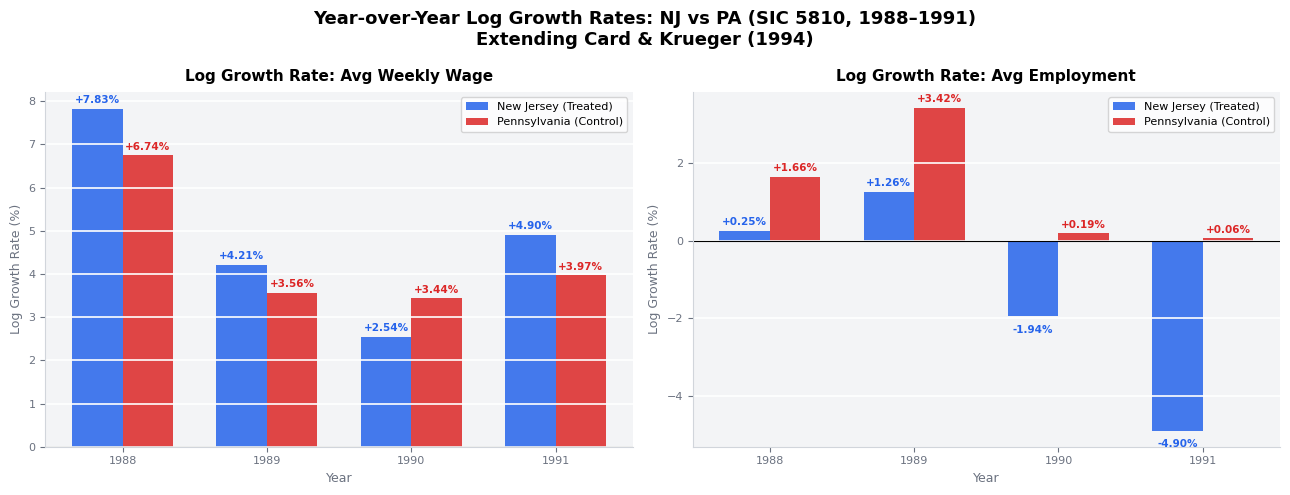

✅ Saved → growth_rates.png


/tmp/ipykernel_393/259503199.py:173: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_393/259503199.py:174: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("normalization_comparison.png", dpi=180,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


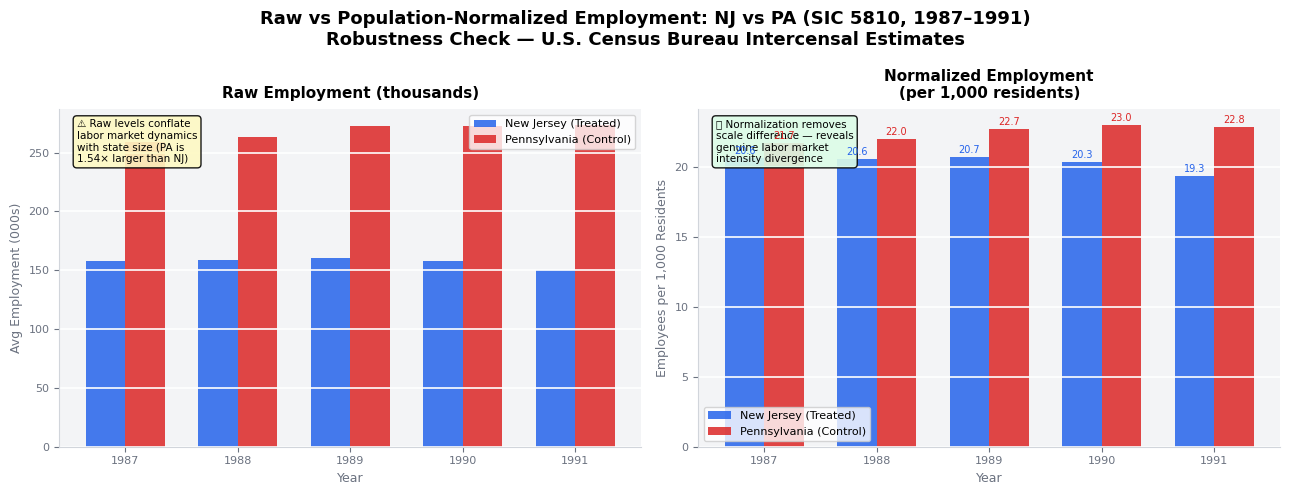

✅ Saved → normalization_comparison.png


/tmp/ipykernel_393/259503199.py:261: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_393/259503199.py:261: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_393/259503199.py:262: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("event_study_bands.png", dpi=180,
/tmp/ipykernel_393/259503199.py:262: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("event_study_bands.png", dpi=180,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

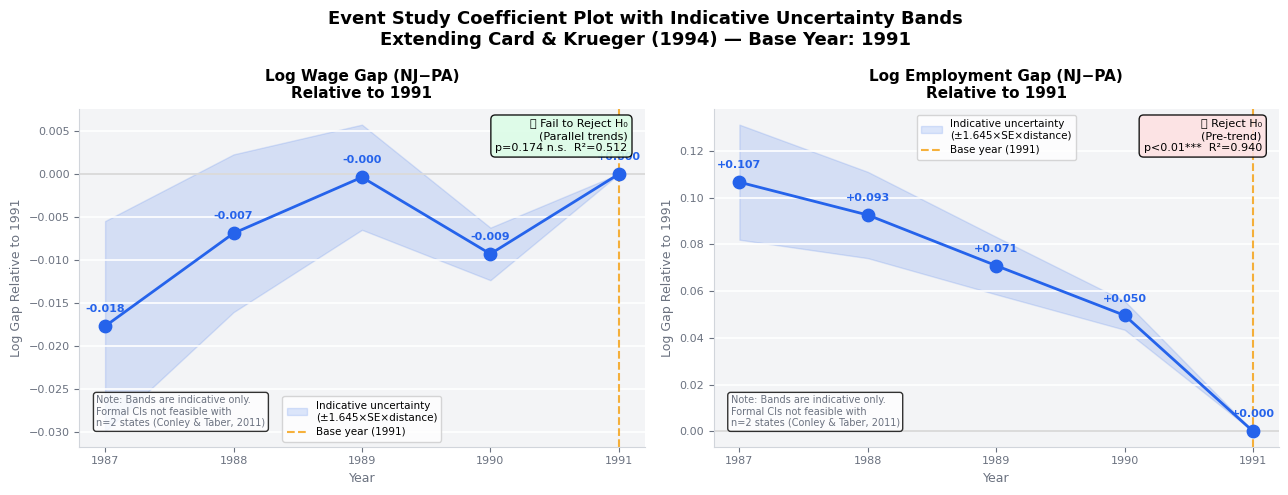

✅ Saved → event_study_bands.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.formula.api as smf

# 0. LOAD DATA & PREP
panel = pd.read_csv("bls_sic5810_panel.csv")
coefs = pd.read_csv("event_study_log_coefs.csv")

nj = panel[panel["state"] == "NJ"].sort_values("year").reset_index(drop=True)
pa = panel[panel["state"] == "PA"].sort_values("year").reset_index(drop=True)

pop = pd.DataFrame({
    "year": [1987, 1988, 1989, 1990, 1991],
    "NJ"  : [7672, 7721, 7764, 7748, 7760],
    "PA"  : [11936, 11961, 11987, 11883, 11961],
})
nj = nj.merge(pop[["year","NJ"]].rename(columns={"NJ":"pop"}), on="year")
pa = pa.merge(pop[["year","PA"]].rename(columns={"PA":"pop"}), on="year")
nj["emp_per_1000"] = nj["avg_employment"] / nj["pop"]
pa["emp_per_1000"] = pa["avg_employment"] / pa["pop"]

nj["log_wage"] = np.log(nj["avg_weekly_wage"])
pa["log_wage"] = np.log(pa["avg_weekly_wage"])
nj["log_emp"]  = np.log(nj["avg_employment"])
pa["log_emp"]  = np.log(pa["avg_employment"])

# Log growth rates (year-over-year % change)
nj["wage_growth"] = nj["log_wage"].diff() * 100
pa["wage_growth"] = pa["log_wage"].diff() * 100
nj["emp_growth"]  = nj["log_emp"].diff() * 100
pa["emp_growth"]  = pa["log_emp"].diff() * 100

# Slope models for uncertainty bands
diff = pd.DataFrame({
    "year"       : nj["year"],
    "t"          : range(1, 6),
    "d_log_wage" : nj["log_wage"] - pa["log_wage"],
    "d_log_emp"  : nj["log_emp"]  - pa["log_emp"],
})
m_wage = smf.ols("d_log_wage ~ t", data=diff).fit()
m_emp  = smf.ols("d_log_emp  ~ t", data=diff).fit()

YEARS   = sorted(panel["year"].unique())
NJ_COL  = "#2563EB"
PA_COL  = "#DC2626"
FIT_COL = "#059669"
GRAY    = "#6B7280"
LIGHT   = "#F3F4F6"

def style_ax(ax, title, ylabel, xlabel="Year"):
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_ylabel(ylabel, fontsize=9, color=GRAY)
    ax.set_xlabel(xlabel, fontsize=9, color=GRAY)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#D1D5DB")
    ax.set_facecolor(LIGHT)
    ax.grid(axis="y", color="white", linewidth=1.2)

# FIGURE 1 — LOG GROWTH RATE BAR CHART
growth_years = YEARS[1:]   # growth rates start from 1988
x     = np.arange(len(growth_years))
width = 0.35

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
fig1.suptitle(
    "Year-over-Year Log Growth Rates: NJ vs PA (SIC 5810, 1988–1991)\n"
    "Extending Card & Krueger (1994)",
    fontsize=13, fontweight="bold"
)

for ax, nj_vals, pa_vals, title, ylabel in [
    (ax1, nj["wage_growth"].dropna().values,
          pa["wage_growth"].dropna().values,
     "Log Growth Rate: Avg Weekly Wage", "Log Growth Rate (%)"),
    (ax2, nj["emp_growth"].dropna().values,
          pa["emp_growth"].dropna().values,
     "Log Growth Rate: Avg Employment",  "Log Growth Rate (%)"),
]:
    b1 = ax.bar(x - width/2, nj_vals, width, color=NJ_COL,
                alpha=0.85, label="New Jersey (Treated)")
    b2 = ax.bar(x + width/2, pa_vals, width, color=PA_COL,
                alpha=0.85, label="Pennsylvania (Control)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(growth_years)

    # Value labels
    for bar in b1:
        h = bar.get_height()
        ax.annotate(f"{h:+.2f}%",
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4 if h >= 0 else -12),
                    textcoords="offset points",
                    fontsize=7.5, ha="center", color=NJ_COL, fontweight="bold")
    for bar in b2:
        h = bar.get_height()
        ax.annotate(f"{h:+.2f}%",
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4 if h >= 0 else -12),
                    textcoords="offset points",
                    fontsize=7.5, ha="center", color=PA_COL, fontweight="bold")

    style_ax(ax, title, ylabel)
    ax.legend(fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig("growth_rates.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Saved → growth_rates.png")

# FIGURE 2 — RAW VS NORMALIZED EMPLOYMENT BAR CHART
x     = np.arange(len(YEARS))
width = 0.35

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
fig2.suptitle(
    "Raw vs Population-Normalized Employment: NJ vs PA (SIC 5810, 1987–1991)\n"
    "Robustness Check — U.S. Census Bureau Intercensal Estimates",
    fontsize=13, fontweight="bold"
)

# Left — raw employment (thousands)
b1 = ax3.bar(x - width/2, nj["avg_employment"]/1000, width,
             color=NJ_COL, alpha=0.85, label="New Jersey (Treated)")
b2 = ax3.bar(x + width/2, pa["avg_employment"]/1000, width,
             color=PA_COL, alpha=0.85, label="Pennsylvania (Control)")
ax3.set_xticks(x)
ax3.set_xticklabels(YEARS)
style_ax(ax3, "Raw Employment (thousands)", "Avg Employment (000s)")
ax3.legend(fontsize=8, framealpha=0.8)
ax3.text(0.03, 0.97,
         "⚠️ Raw levels conflate\nlabor market dynamics\nwith state size (PA is\n1.54× larger than NJ)",
         transform=ax3.transAxes, fontsize=7.5, va="top",
         bbox=dict(boxstyle="round,pad=0.35", facecolor="#FEF9C3", alpha=0.9))

# Right — normalized employment per 1,000 residents
b3 = ax4.bar(x - width/2, nj["emp_per_1000"], width,
             color=NJ_COL, alpha=0.85, label="New Jersey (Treated)")
b4 = ax4.bar(x + width/2, pa["emp_per_1000"], width,
             color=PA_COL, alpha=0.85, label="Pennsylvania (Control)")
ax4.set_xticks(x)
ax4.set_xticklabels(YEARS)
style_ax(ax4, "Normalized Employment\n(per 1,000 residents)", "Employees per 1,000 Residents")
ax4.legend(fontsize=8, framealpha=0.8)
ax4.text(0.03, 0.97,
         "✅ Normalization removes\nscale difference — reveals\ngenuine labor market\nintensity divergence",
         transform=ax4.transAxes, fontsize=7.5, va="top",
         bbox=dict(boxstyle="round,pad=0.35", facecolor="#DCFCE7", alpha=0.9))

# Value labels for normalized bars
for bar in b3:
    h = bar.get_height()
    ax4.annotate(f"{h:.1f}",
                 xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points",
                 fontsize=7, ha="center", color=NJ_COL)
for bar in b4:
    h = bar.get_height()
    ax4.annotate(f"{h:.1f}",
                 xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points",
                 fontsize=7, ha="center", color=PA_COL)

plt.tight_layout()
plt.savefig("normalization_comparison.png", dpi=180,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Saved → normalization_comparison.png")

# ============================================================
# FIGURE 3 — COEFFICIENT PLOT WITH UNCERTAINTY BANDS
# ============================================================
BASE_YEAR = 1991
wage_coefs = coefs[coefs["outcome"] == "Log Wage Gap"].sort_values("year")
emp_coefs  = coefs[coefs["outcome"] == "Log Emp Gap"].sort_values("year")

# Uncertainty band: ±1.645 × SE × |t - t_base|
# SE from slope test, scaled by distance from base year
# Clearly labeled as indicative — NOT formal CIs
t_vals   = np.array([1, 2, 3, 4, 5])
t_base   = 5   # 1991 = t=5
t_dist   = np.abs(t_vals - t_base)

se_wage  = m_wage.bse["t"]
se_emp   = m_emp.bse["t"]

band_wage = 1.645 * se_wage * t_dist
band_emp  = 1.645 * se_emp  * t_dist

w_coef = wage_coefs["coef"].values
e_coef = emp_coefs["coef"].values

fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
fig3.suptitle(
    "Event Study Coefficient Plot with Indicative Uncertainty Bands\n"
    "Extending Card & Krueger (1994) — Base Year: 1991",
    fontsize=13, fontweight="bold"
)

for ax, coef_vals, band, title, ylabel, model in [
    (ax5, w_coef, band_wage,
     "Log Wage Gap (NJ−PA)\nRelative to 1991",
     "Log Gap Relative to 1991", m_wage),
    (ax6, e_coef, band_emp,
     "Log Employment Gap (NJ−PA)\nRelative to 1991",
     "Log Gap Relative to 1991", m_emp),
]:
    p  = model.pvalues["t"]
    b  = model.params["t"]
    r2 = model.rsquared
    sig = "p<0.01***" if p<0.01 else "p<0.05**" if p<0.05 \
          else "p<0.10*" if p<0.10 else f"p={p:.3f} n.s."

    # Uncertainty band
    ax.fill_between(YEARS,
                    coef_vals - band,
                    coef_vals + band,
                    color=NJ_COL, alpha=0.15,
                    label="Indicative uncertainty\n(±1.645×SE×distance)")

    ax.axhline(0, color="black", linewidth=1.2, zorder=1)
    ax.axvline(BASE_YEAR, color="#F59E0B", linewidth=1.5,
               linestyle="--", alpha=0.8, label=f"Base year ({BASE_YEAR})")
    ax.scatter(YEARS, coef_vals, color=NJ_COL, s=80, zorder=4)
    ax.plot(YEARS, coef_vals, color=NJ_COL, linewidth=2, zorder=3)

    for yr, c in zip(YEARS, coef_vals):
        ax.annotate(f"{c:+.3f}",
                    xy=(yr, c), xytext=(0, 10),
                    textcoords="offset points",
                    fontsize=8, ha="center",
                    color=NJ_COL, fontweight="bold")

    style_ax(ax, title, ylabel)
    ax.set_xticks(YEARS)
    ax.legend(fontsize=7.5, framealpha=0.8)

    rc = "#FEE2E2" if p < 0.1 else "#DCFCE7"
    rt = "❌ Reject H₀\n(Pre-trend)" if p < 0.1 \
         else "✅ Fail to Reject H₀\n(Parallel trends)"
    ax.text(0.97, 0.97,
            f"{rt}\n{sig}  R²={r2:.3f}",
            transform=ax.transAxes, fontsize=8,
            ha="right", va="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor=rc, alpha=0.9))

    ax.text(0.03, 0.06,
            "Note: Bands are indicative only.\nFormal CIs not feasible with\nn=2 states (Conley & Taber, 2011)",
            transform=ax.transAxes, fontsize=7, color=GRAY,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("event_study_bands.png", dpi=180,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Saved → event_study_bands.png")

# Executive Summary

Card & Krueger (1994) used a Difference-in-Differences estimate to compare employment
changes in NJ (treated) vs PA (control) to provide evidence that the wage hike in 1992
did not affect employment in NJ negatively. They assumed that the two states have similar
economies in that they have parallel wage and employment trends before the wage hike and
will continue to do so after the wage hike. This is a critical limitation because the
entire DiD identification relies on the parallel trends assumption, which the paper never
formally tests. Thus, to improve the comparability of the two states, wage and employment
trends between the two states are tested through an event study to show that they are
parallel before the wage hike in 1992. Data is extracted from BLS QCEW annual data for
the Eating and Drinking Places sector (SIC 5810) from 1987–1991, then a log-scale slope
trend test was applied, consistent with the paper, where a coefficient that is statistically
significant would mean that the parallel trends assumption is violated. To
further improve robustness and ensure that any difference in employment shown by the prior
test reflects labor market differences rather than demographic differences, employment was
normalized by state population using population data from U.S. Census Bureau intercensal
estimates.

The findings put Card & Krueger's conclusions into perspective, rather than invalidating
or strengthening them. Firstly, the slope test for wages fails to reject the null hypothesis,
which supports the parallel trends assumption in the wage dimension and corroborates the
paper's wage-related findings. However, this is still not definitive support, as the trend
explains only around 51% of the variance in the wage gap as evidence by R-squared. As for employment, both the raw
and normalized event studies show violations of the parallel trends assumption. The violation
strengthens after normalization, which confirms that the difference is genuinely due to labor
market dynamics rather than demographic composition. As seen in the graph, NJ's per-capita
food service employment was already on a declining trend relative to PA at 2.5% annually
before the wage hike. This suggests that the paper's wage findings have solid support, but
their employment findings should be approached cautiously. The pre-existing difference in
employment trends may indicate that the DiD estimate captures a trend that was already
underway, rather than the causal effect of the policy.